LangGraph is a framework for building agent workflows as graphs
LangGraph lets you define an agent as a set of connected steps, instead of just a single model call or a hidden runtime loop.

Core idea
Think of it like this:

a node = one step in the workflow
an edge = the path from one step to the next
state = the shared information flowing through the graph
a checkpoint = a saved snapshot of that state
So instead of “the model just does stuff,” LangGraph says:

“Here is the exact workflow: call the model, decide whether to use a tool, run the tool, feed results back, repeat, then stop.”

```mermaid
flowchart TD
    A["Start"] --> B["llm_call"]
    B --> C{"Tool call?"}
    C -->|Yes| D["tool_node"]
    D --> B
    C -->|No| E["Final answer / END"]
```


Your earlier hand-written agent loop was:

call model
see if it wants a tool
run the tool
append result to messages
call model again
repeat until final answer
LangGraph makes that explicit as a graph:

Compared to `create_agent(...)`, the graph API makes every step explicit.

The application defines:

- what the **state** looks like
- which **nodes** exist
- when the graph should continue
- when it should stop

This layer trades a small amount of additional code for clearer customization boundaries.

LangChain is a framework for building LLM applications quickly, while LangGraph is a graph-based runtime for defining explicit, stateful agent workflows and control flow. Use LangChain for simpler agent setup and LangGraph when you need custom routing, memory, or inspectable multi-step execution.



Examples of when to use each
LangChain example
Use LangChain when you want a quick AI assistant with tools:

LangChain example
Use LangChain when you want a quick AI assistant with tools:
```python
agent = create_agent(
    model=model,
    tools=[multiply, string_length],
    system_prompt="Use tools for math and counting."
)```
This is great for:

a small chatbot
a tool-using assistant
quick prototyping
app logic without manually writing the loop

LangGraph example
Use LangGraph when you want full control over the workflow:
```python
builder = StateGraph(MessagesState)
builder.add_node("llm_call", llm_call)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_call")
builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
builder.add_edge("tool_node", "llm_call")
app = builder.compile()
```
This is useful for:

agents with branching logic
stateful workflows
explicit checkpoints
debugging the exact sequence of steps
custom memory and routing rules


## How the graph loop works

The loop is still the same idea as in notebook 1.

At a high level, it works like this:

1. call the model
2. check whether the model asked for a tool
3. run the tool if needed
4. add the result back into the conversation
5. stop when the model returns a final answer

The main difference is that now we define that flow ourselves. The graph keeps everything connected through a shared **state** object.

## Control-flow sketch

```mermaid
flowchart LR
    S["START"] --> L["llm_call"]
    L --> C{"tool call?"}
    C -->|yes| T["tool_node"]
    T --> L
    C -->|no| E["END"]
```

This is the full pattern for this notebook: start, call the model, optionally run tools, then either continue or stop.


```mermaid
flowchart TD
    A["Initialize model"] --> B["Define tools"]
    B --> C["Define shared state"]
    C --> D["llm_call node"]
    D --> E{"Last AI message has tool calls?"}
    E -->|Yes| F["tool_node runs Python tool(s)"]
    F --> G["Append tool results to messages"]
    G --> D
    E -->|No| H["Final answer returned"]

    H --> I["Compile graph"]
    I --> J["Render graph image"]
    J --> K["Invoke graph with thread_id"]
    K --> L["Inspect message trace"]
    L --> M["Stream updates"]
    M --> N["Reuse same thread for memory"]
    N --> O["Inspect checkpoint state"]
    O --> P["Inspect state history"]

    subgraph Memory["Memory / Checkpoints"]
        N
        O
        P
    end
```

This overview connects the full LangGraph workflow: initialize the model, attach tools, define state, route between the model and tool node, compile the graph, run it with a thread, and inspect checkpoints and message history.

In [1]:
import operator  # standard math/logic operators
from typing import Annotated, Any, TypedDict, cast  # type hints

from dotenv import load_dotenv  # read secret keys from a .env file
from IPython.display import Image, display  # show images inside the notebook
from langchain.chat_models import (
    init_chat_model,
)  # choose and connect to an AI model (e.g. GPT)
from langchain.messages import (  # message formats for the AI conversation
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain.tools import (
    tool,
)  # turn a regular Python function into a tool the agent can use
from langchain_core.runnables import (
    RunnableConfig,
)  # extra options you can pass when running the agent
from langgraph.checkpoint.memory import (
    InMemorySaver,
)  # remember what the agent did so it can continue later
from langgraph.graph import (
    END,
    START,
    StateGraph,
)  # define the steps and flow of the agent
from langgraph.graph.message import (
    add_messages,
)  # keep track of messages as they flow through the agent

## Initialize the model and tools

This setup is almost the same as in the previous notebook. We load the model, define a few math tools, and then bind those tools to the model.

`model.bind_tools(tools)` is what lets the model return tool calls instead of only plain text.

In [2]:
load_dotenv(".env")

model = init_chat_model("groq:openai/gpt-oss-20b", temperature=0)


@tool
def add(a: int, b: int) -> int:
    """Add two integers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


@tool
def divide(a: int, b: int) -> float:
    """Divide a by b."""
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

## Define state

The **state** is the shared data the graph carries from one node to the next.

It behaves like a shared state object: each step reads from it, updates it, and passes it on.

Here we track:

- `messages`: the full conversation so far (every message in, every message out)
- `llm_calls`: how many times we have called the AI model
- `tool_names`: which tools were used during the run

`add_messages` tells LangGraph how to keep extending the message list, and `operator.add` does the same for `tool_names`.

Each node returns only the fields it wants to update. LangGraph then merges those updates into the existing state. Reducers define the merge behavior for fields that should accumulate over time. Here, `add_messages` appends messages while preserving message semantics, and `operator.add` appends tool names to the list.


In [3]:
class MessagesState(TypedDict, total=False):
    messages: Annotated[list[AnyMessage], add_messages]
    llm_calls: int
    tool_names: Annotated[list[str], operator.add]

## Model node

This node is the step where the graph calls the model.

It takes the current `messages`, adds a **system message** at the front, and sends the full list to `model_with_tools`.

The returned `AIMessage` is stored back in the state, and `llm_calls` is incremented so we can see how many model calls happened during the run.

In [4]:
def llm_call(state: MessagesState):
    # This node performs one model step. It may produce a final answer or tool calls.
    response = model_with_tools.invoke(
        [
            SystemMessage(
                content=(
                    "You are a careful math assistant. "
                    "Use tools for arithmetic and keep the final answer concise."
                )
            ),
            *state["messages"],
        ]
    )
    return {
        # The reducer appends this response to the existing message history.
        "messages": [response],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }

## Tool node

The model does not run Python functions by itself. Instead, it returns a tool request: which tool to call and which arguments to use.

This node reads those requests, runs the matching Python functions, and turns the results into `ToolMessage` objects.

Those messages are added back into the conversation so the model can continue from there.

“Take the current conversation, tell the model to act like a careful math assistant, ask it what it wants to do next, append its answer to the state, and count this as one model call.”

In [5]:
def tool_node(state: MessagesState):
    outputs = []
    last_message = cast(AIMessage, state["messages"][-1])

    for tool_call in last_message.tool_calls:
        # The model chose the tool name and arguments; Python executes the tool.
        result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"],
            )
        )

    return {
        "messages": outputs,
        "tool_names": [tool_call["name"] for tool_call in last_message.tool_calls],
    }

## Router

This function decides where the graph goes next.

If the last `AIMessage` contains a tool call, the graph moves to `tool_node`. If not, it goes to `END`.

This is the edge that turns the graph into a loop.

A regular model call stops after one response. The router is what turns repeated model calls and tool calls into a controlled loop. The graph continues only when the latest model message contains tool calls; otherwise it terminates at `END`.


In [6]:
def should_continue(state: MessagesState):
    last_message = cast(AIMessage, state["messages"][-1])
    return "tool_node" if last_message.tool_calls else END

## Compile and render the graph

Up to this point, `builder` is only the graph definition. In the next cell, we connect the nodes, add the edges, and compile the graph into a runnable app.

Passing `InMemorySaver()` enables checkpoints. That means the graph can save its state after each step so we can inspect it later.

The final line renders the graph as an image so we can confirm the flow looks the way we expect.

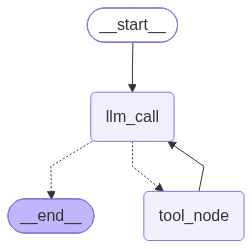

In [7]:
builder = StateGraph(
    cast(Any, MessagesState)
)  # create a new graph with our state shape

builder.add_node("llm_call", llm_call)  # node 1: send messages to the AI model
builder.add_node("tool_node", tool_node)  # node 2: run the tool the AI asked for

builder.add_edge(START, "llm_call")  # always start by calling the AI
builder.add_conditional_edges(  # after the AI responds, decide what to do next:
    "llm_call",
    should_continue,
    ["tool_node", END],  #   → run a tool, or stop if we're done
)
builder.add_edge("tool_node", "llm_call")  # after running a tool, go back to the AI

app = builder.compile(
    checkpointer=InMemorySaver()
)  # lock in the graph and enable memory

display(
    Image(app.get_graph(xray=True).draw_mermaid_png())
)  # show a diagram of the graph

## Invoke the graph

`app.invoke()` runs the graph from `START` to `END`.

Instead of passing a plain prompt string, we pass a state dictionary with an initial `HumanMessage`.

We also pass a `thread_id` in the config. LangGraph uses that ID to store and look up checkpoints for this conversation.

In [8]:
# Define the initial input to the agent, which will be passed to the first node when we run it.
first_input = {
    "messages": [
        HumanMessage(
            content="Add 3 and 4, then multiply the answer by 5, then divide by 7."
        )
    ]
}

# Define config with thread_id to keep all runs of this agent in the same thread.
config: RunnableConfig = {"configurable": {"thread_id": "langgraph-math-run"}}

first_run = app.invoke(first_input, config=config)
first_run["messages"][-1].content

'5.0'

## Inspect the message trace

Like the agent in notebook 1, this graph returns the full message history, not just the final answer.

The helper below formats those messages into a simpler list so it is easier to inspect what happened step by step.

In [9]:
def summarize_messages(messages):
    rows = []
    for index, message in enumerate(messages):
        rows.append(
            {
                "index": index,
                "type": type(message).__name__,
                "content": getattr(message, "content", None),
                "tool_calls": getattr(message, "tool_calls", None),
            }
        )
    return rows

In [10]:
{
    "final_answer": first_run["messages"][-1].content,
    "llm_calls": first_run["llm_calls"],
    "tool_names": first_run["tool_names"],
    "message_trace": summarize_messages(first_run["messages"]),
}

{'final_answer': '5.0',
 'llm_calls': 4,
 'tool_names': ['add', 'multiply', 'divide'],
 'message_trace': [{'index': 0,
   'type': 'HumanMessage',
   'content': 'Add 3 and 4, then multiply the answer by 5, then divide by 7.',
   'tool_calls': None},
  {'index': 1,
   'type': 'AIMessage',
   'content': '',
   'tool_calls': [{'name': 'add',
     'args': {'a': 3, 'b': 4},
     'id': 'fc_3617c1cb-182d-42d2-8b0b-6e04dac7e764',
     'type': 'tool_call'}]},
  {'index': 2, 'type': 'ToolMessage', 'content': '7', 'tool_calls': None},
  {'index': 3,
   'type': 'AIMessage',
   'content': '',
   'tool_calls': [{'name': 'multiply',
     'args': {'a': 7, 'b': 5},
     'id': 'fc_0df626d1-c610-4eda-9327-c46ddf3de503',
     'type': 'tool_call'}]},
  {'index': 4, 'type': 'ToolMessage', 'content': '35', 'tool_calls': None},
  {'index': 5,
   'type': 'AIMessage',
   'content': '',
   'tool_calls': [{'name': 'divide',
     'args': {'a': 35, 'b': 7},
     'id': 'fc_8207705f-cdb7-4678-b90d-75b7d4923ec4',
     

The graph solved `(3 + 4) * 5 / 7` and returned `The answer is 5.0.`. Two state fields explain the loop: `llm_calls` is 2, and `tool_names` is `['add', 'multiply', 'divide']`. The model emitted all three tool calls in a single message and filled in the intermediate values itself (multiply by 5, divide by 7), so the graph only needed one more model call to write the final answer. That is why two model calls were enough.

## Stream state updates

So far we have used `app.invoke()`, which waits until the whole graph is finished and then returns the final state.

`app.stream()` also runs the graph from start to finish, but it emits updates for each step along the way. This makes it useful when you want the intermediate steps in a more direct form, instead of reconstructing them afterward from the final state.

`stream_mode="updates"` returns one item per node update. That makes it possible to build progress indicators, logs, or debugging views without waiting for the final graph state. The final `invoke(...)` output is still useful, but streaming exposes the path the graph took to get there.


In [11]:
streamed_updates = list(
    app.stream(
        {
            "messages": [
                HumanMessage(content="Add 10 and 5, then divide the answer by 3.")
            ]
        },
        config={"configurable": {"thread_id": "langgraph-stream-run"}},
        stream_mode="updates",
    )
)
streamed_updates

[{'llm_call': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to add 10 and 5, then divide by 3. Use functions. First add 10 and 5. Then divide result by 3.', 'tool_calls': [{'id': 'fc_1b85226b-383d-4d55-aab6-05fc1ac3abf7', 'function': {'arguments': '{"a":10,"b":5}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 201, 'total_tokens': 262, 'completion_time': 0.068232889, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.032309019, 'prompt_tokens_details': None, 'queue_time': 0.321214976, 'total_time': 0.100541908}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66891002f6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d761-2ca4-75c2-8d85-deb4d29525fe-0', tool_calls=[{'name': 'add', 'args': {'a': 10, 'b': 5}, 'id': 'fc_1b85226b-383d-4d55-aab6-05fc1ac3abf7', 'type': 'tool_c

With `stream_mode="updates"`, each item is one node's update to the state. You can see `llm_call` and `tool_node` emit their changes in order. This is what makes streaming useful for progress indicators, logs, or debugging: you watch the path the graph takes instead of waiting for the final state.

## Reuse the same thread for memory

Memory is tied to `thread_id`, not to a Python variable.

The two calls below reuse the same thread, so the second one can continue from the first.

This is the same idea as notebook 1, but now we can see the graph-level pieces directly.

In [12]:
memory_config: RunnableConfig = {"configurable": {"thread_id": "langgraph-memory-run"}}

first_run = app.invoke(
    {
        "messages": [
            HumanMessage(content="My preferred threshold is 12. Also compute 2 plus 2.")
        ]
    },
    config=memory_config,
)

In [13]:
second_run = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="What is my preferred threshold, and what is 1 plus that number?"
            )
        ]
    },
    config=memory_config,
)

second_run["messages"][-1].content

'Your preferred threshold is **12**.  \nAdding 1 gives **13**.'

The second call reuses the same `thread_id`, so the graph still holds the earlier turn in state. It recalls the preferred threshold of 12 and computes `1 + 12 = 13`. Memory here is the saved checkpoint for that thread, not a Python variable.

## Inspect the saved checkpoint

A **checkpoint** is a saved snapshot of the graph state.

`get_state()` returns the latest checkpoint for a given `thread_id`, so we can inspect what the graph currently knows in that conversation.

In [14]:
state_snapshot = app.get_state(memory_config)
{
    "next": state_snapshot.next,
    "values": state_snapshot.values,
}

{'next': (),
 'values': {'messages': [HumanMessage(content='My preferred threshold is 12. Also compute 2 plus 2.', additional_kwargs={}, response_metadata={}, id='0439edbf-62a1-4af5-84ce-03370d9ca1c5'),
   AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to respond: threshold is 12. Also compute 2+2. Use tool add.', 'tool_calls': [{'id': 'fc_c4dffc48-6bc4-4753-b93d-5133622f6ef2', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 201, 'total_tokens': 249, 'completion_time': 0.050957875, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.011454168, 'prompt_tokens_details': None, 'queue_time': 0.346482427, 'total_time': 0.062412043}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_feb9b278f1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d761-3238-7d1

## Inspect state history

`get_state_history()` goes one step further. Instead of only the latest checkpoint, it returns a snapshot for each step that ran.

That makes it easier to see how the state changed over time.

In [15]:
history = list(app.get_state_history(memory_config))[:3]
[
    {
        "step": (snapshot.metadata or {}).get("step"),
        "source": (snapshot.metadata or {}).get("source"),
        "next": snapshot.next,
        "keys": sorted(snapshot.values.keys()),
    }
    for snapshot in history
]

[{'step': 8,
  'source': 'loop',
  'next': (),
  'keys': ['llm_calls', 'messages', 'tool_names']},
 {'step': 7,
  'source': 'loop',
  'next': ('llm_call',),
  'keys': ['llm_calls', 'messages', 'tool_names']},
 {'step': 6,
  'source': 'loop',
  'next': ('tool_node',),
  'keys': ['llm_calls', 'messages', 'tool_names']}]

`get_state_history()` returns one snapshot per step. The steps count down from the latest (here 8, then 7, then 6), and each snapshot records what ran and what comes `next`. This trail is what you inspect to debug or audit how the graph reached its result.

## Summary

In this notebook you:

- Built an agent loop with the LangGraph Graph API from explicit state, nodes, and edges.
- Applied the `add_messages` and `operator.add` reducers so messages and tool names accumulate.
- Routed with a conditional edge to loop through tools or stop at the answer.
- Inspected checkpoints and state history to follow how the state changed across a run.

In the next notebook, you build on this with structured output, streaming, and interrupts.

## References & Further Reading

- [**LangGraph Quickstart**](https://docs.langchain.com/oss/python/langgraph/quickstart): Building an agent with the Graph API and the Functional API.
- [**Graph API Overview**](https://docs.langchain.com/oss/python/langgraph/graph-api): Nodes, edges, and state in LangGraph.
- [**Memory in LangGraph**](https://docs.langchain.com/oss/python/langgraph/add-memory): Checkpointers and threads for persistent state.
- [**Streaming**](https://docs.langchain.com/oss/python/langgraph/streaming): The streaming modes for graph runs.